# Introduction au Machine Learning

##### Importation des packages de base

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

##### On charge le dataset

In [4]:
digits = load_digits()

#### On affiche les 4 premières images

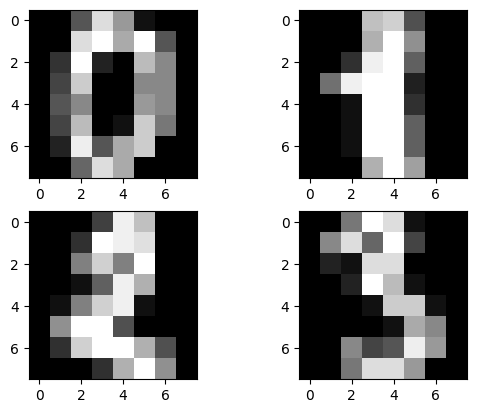

In [ ]:
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.imshow(digits.images[i],cmap='gray')
plt.show()

##### Exploration des données

In [6]:
print(f"Colonnes du dataset : {digits.keys()}")
print(f"Targets possibles   : {digits.target_names}")
print(f"Première image :\n{digits.images[0]}")
print(f"Nombre total d'images : {digits.images.shape[0]}")

unique, counts = np.unique(digits.target, return_counts=True)
print("Nombre d'occurrences pour chaque chiffre :")
for val, count in zip(unique, counts):
    print(f"{val} : {count} images")

Colonnes du dataset : dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])
Targets possibles   : [0 1 2 3 4 5 6 7 8 9]
Première image :
[[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]
Nombre total d'images : 1797
Nombre d'occurrences pour chaque chiffre :
0 : 178 images
1 : 182 images
2 : 177 images
3 : 183 images
4 : 181 images
5 : 182 images
6 : 181 images
7 : 179 images
8 : 174 images
9 : 180 images


##### On crée notre feature matrix et notre vecteur de labels

In [7]:
X = digits.data
y = digits.target

print(f"Feature matrix shape: {X.shape}. Max value = {np.max(X)}, Min value = {np.min(X)}, Mean value = {np.mean(X)}")
print(f"Labels shape: {y.shape}")

Feature matrix shape: (1797, 64). Max value = 16.0, Min value = 0.0, Mean value = 4.884164579855314
Labels shape: (1797,)


Le "label" valeur exacte dans l'échantillon et la "taget" est la valeur à predire

##### On normalise nos valeurs

In [8]:
F = X/16

print(f"Feature matrix F shape: {F.shape}. Max value = {np.max(F)}, Min value = {np.min(F)}, Mean value = {np.mean(F)}")

Feature matrix F shape: (1797, 64). Max value = 1.0, Min value = 0.0, Mean value = 0.30526028624095713


##### On réduit la dimensions des datas

In [9]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
F_pca = pca.fit_transform(F) 

On plot en 2D le résultat

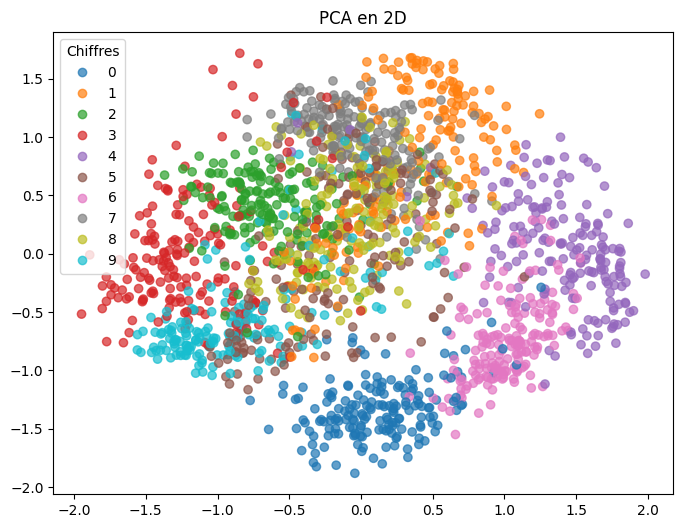

In [23]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(F_pca[:, 0], F_pca[:, 1], c=digits.target, cmap='tab10', alpha=0.7)
plt.legend(*scatter.legend_elements(), title="Chiffres")
plt.title("PCA en 2D")
plt.savefig("../../img/scattle_pca.png")

On remarque que les chiffres sont plutot groupé entre eux, ce qui nous donne une piste pour savoir de quel chiffre il sagit selon sa position sur le graphe.

##### On reconstruit à partir de cette réduction

In [18]:
from sklearn.metrics import mean_squared_error
F_ipca = pca.inverse_transform(F_pca)
print(f"L'erreur quadratique moyenne est :", mean_squared_error(F, F_ipca))

L'erreur quadratique moyenne est : 0.052425828909224405


##### On compare nos deux images

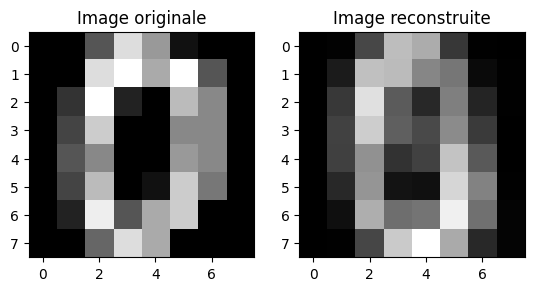

In [22]:
plt.subplot(1,2,1)
img0 = X[0].reshape(8,8)
plt.imshow(img0,cmap='gray')
plt.title("Image originale")

plt.subplot(1,2,2)
img1 = F_ipca[0].reshape(8,8)
plt.imshow(img1,cmap='gray')
plt.title("Image reconstruite")

plt.savefig("../../img/comparaison.png")